<a href="https://colab.research.google.com/github/hrishikeshrprasad367/ML/blob/main/Lab7/1BM23CS367_Lab_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

letter=pd.read_csv("letter-recognition.csv")
print(letter.head())
print(letter.describe())

  letter  xbox   ybox   width   height  onpix   xbar   ybar   x2bar  y2bar   \
0      T      2      8       3       5       1      8     13      0       6   
1      I      5     12       3       7       2     10      5      5       4   
2      D      4     11       6       8       6     10      6      2       6   
3      N      7     11       6       6       3      5      9      4       6   
4      G      2      1       3       1       1      8      6      6       6   

   xybar   x2ybar  xy2bar  xedge   xedgey  yedge   yedgex  
0       6      10       8       0       8       0       8  
1      13       3       9       2       8       4      10  
2      10       3       7       3       7       3       9  
3       4       4      10       6      10       2       8  
4       6       5       9       1       7       5      10  
              xbox          ybox         width        height        onpix   \
count  20000.000000  20000.000000  20000.000000  20000.00000  20000.000000   
mean     

=== RBF Kernel ===
Accuracy: 0.9305


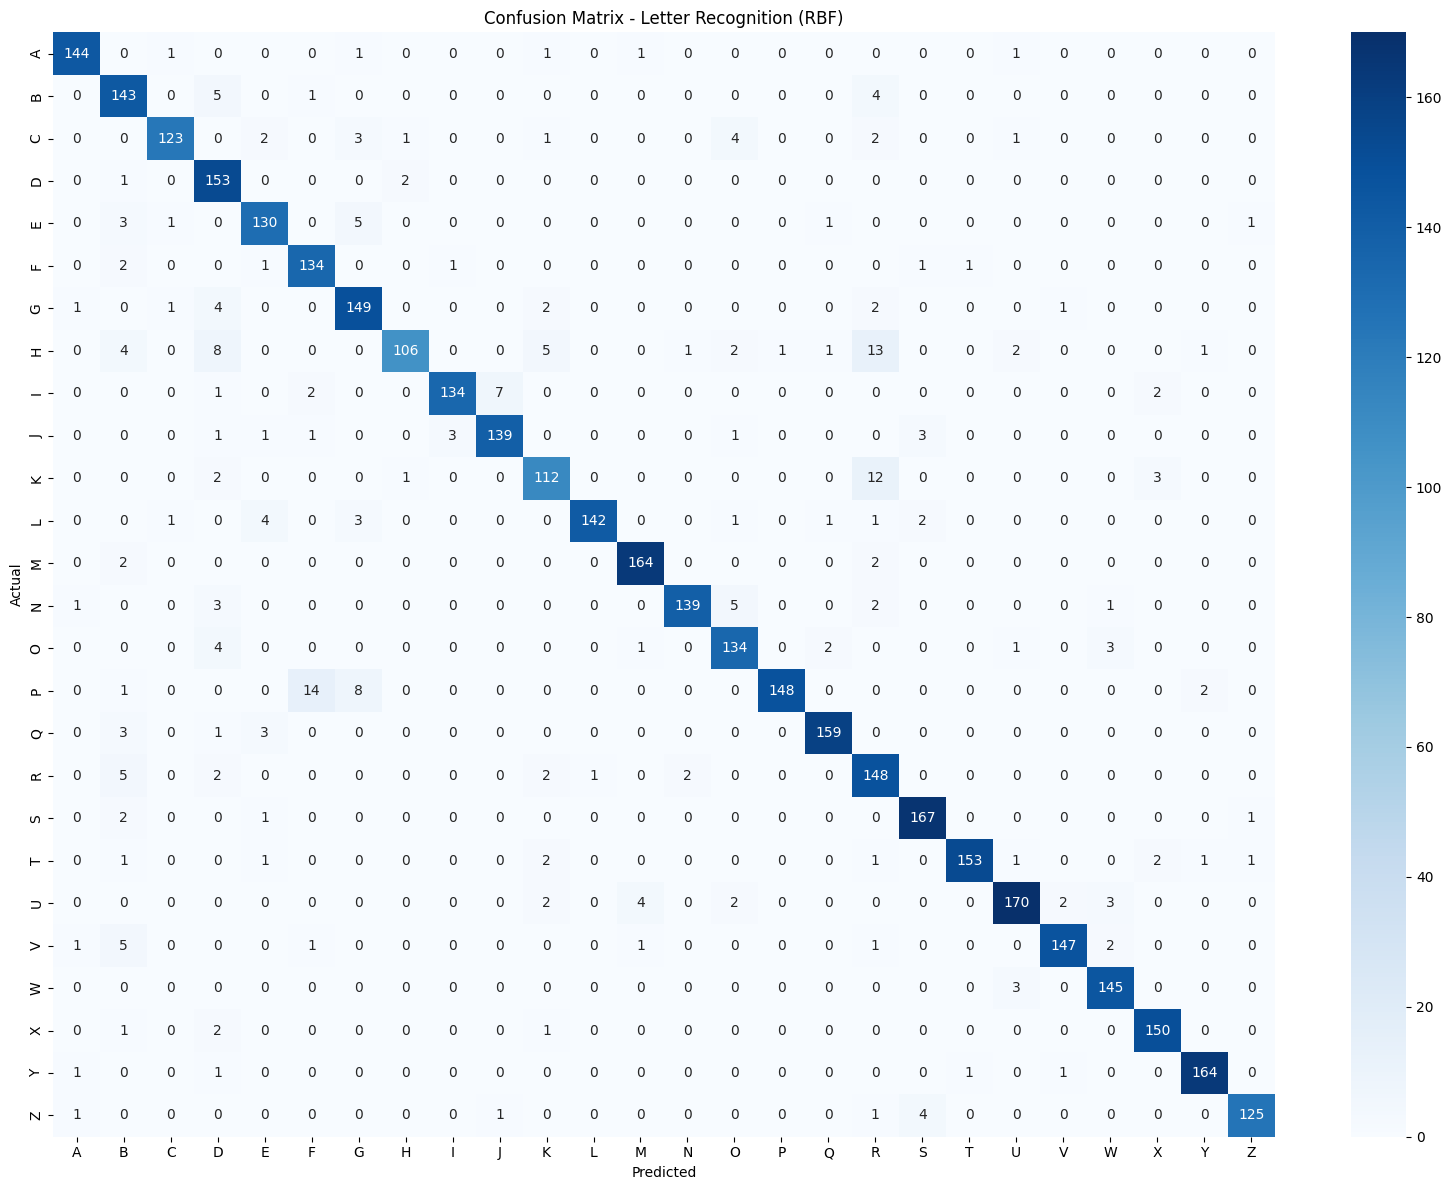

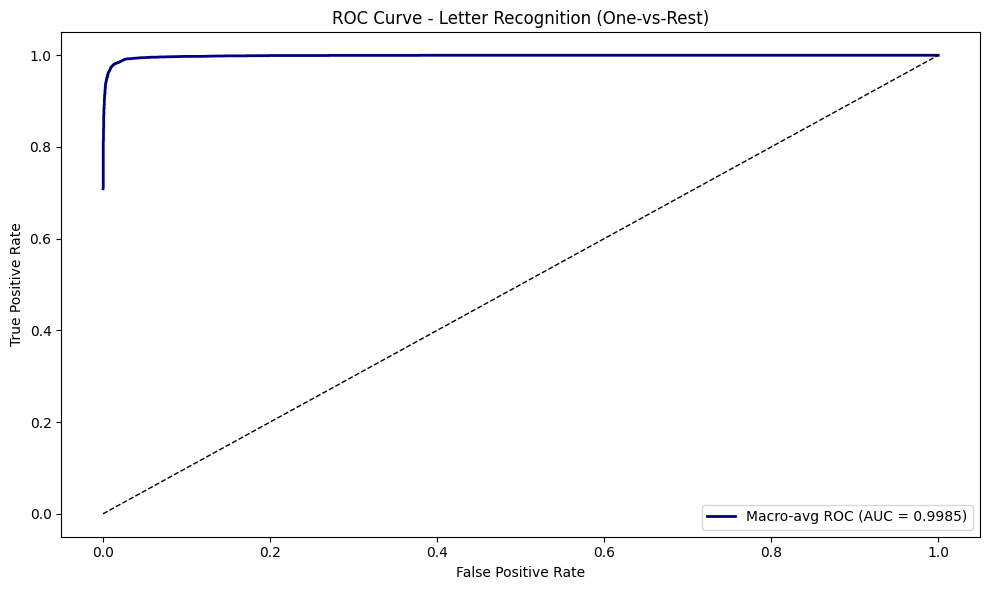


Macro-Average AUC Score: 0.9985


In [2]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import LabelBinarizer
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Prepare features and target
X = letter.drop('letter', axis=1)
y = letter['letter']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build SVM with RBF kernel
svm_rbf = SVC(kernel='rbf', probability=True)
svm_rbf.fit(X_train, y_train)
y_pred_rbf = svm_rbf.predict(X_test)

print("=== RBF Kernel ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rbf):.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rbf)
plt.figure(figsize=(16, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=svm_rbf.classes_,
            yticklabels=svm_rbf.classes_)
plt.title('Confusion Matrix - Letter Recognition (RBF)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# ROC Curve (One-vs-Rest for multiclass)
lb = LabelBinarizer()
y_test_bin = lb.fit_transform(y_test)
y_score = svm_rbf.predict_proba(X_test)

# Compute macro-average ROC
fpr, tpr, roc_auc = {}, {}, {}
n_classes = len(lb.classes_)

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Macro average
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes
macro_auc = auc(all_fpr, mean_tpr)

plt.figure(figsize=(10, 6))
plt.plot(all_fpr, mean_tpr, color='navy', lw=2,
         label=f'Macro-avg ROC (AUC = {macro_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Letter Recognition (One-vs-Rest)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"\nMacro-Average AUC Score: {macro_auc:.4f}")

RBF Kernel Accuracy: 1.0000
Linear Kernel Accuracy: 1.0000


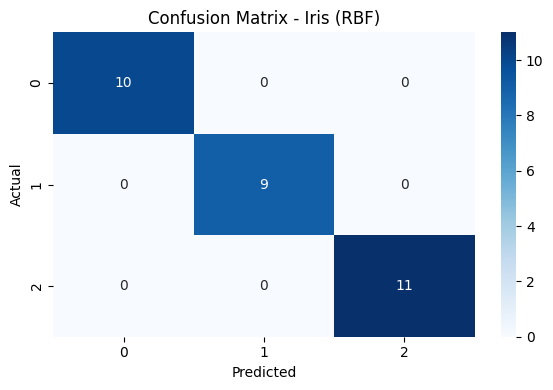

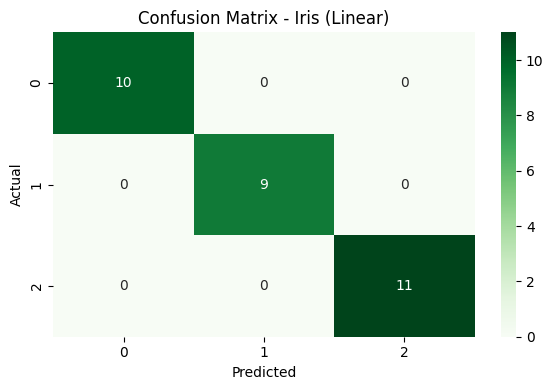

In [3]:
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
iris = pd.read_csv("iris.csv")
X = iris.drop('species', axis=1)  # change 'species' to your actual target column name
y = iris['species']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- RBF Kernel ---
svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(X_train, y_train)
y_pred_rbf = svm_rbf.predict(X_test)
acc_rbf = accuracy_score(y_test, y_pred_rbf)
print(f"RBF Kernel Accuracy: {acc_rbf:.4f}")

# --- Linear Kernel ---
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train, y_train)
y_pred_linear = svm_linear.predict(X_test)
acc_linear = accuracy_score(y_test, y_pred_linear)
print(f"Linear Kernel Accuracy: {acc_linear:.4f}")

# Confusion Matrix - RBF
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_rbf), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Iris (RBF)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Confusion Matrix - Linear
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_linear), annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Iris (Linear)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

RF Accuracy (n_estimators=10): 1.0000


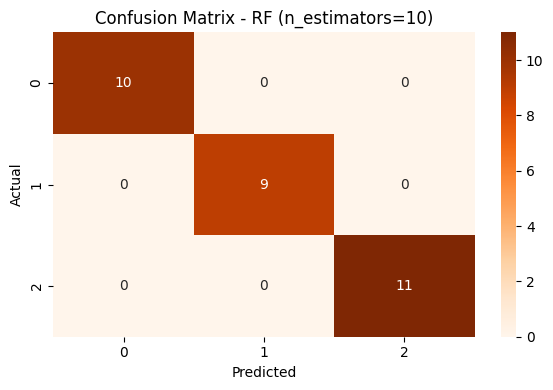

n_estimators=   1  ->  Accuracy: 1.0000
n_estimators=   5  ->  Accuracy: 0.9667
n_estimators=  10  ->  Accuracy: 1.0000
n_estimators=  20  ->  Accuracy: 1.0000
n_estimators=  50  ->  Accuracy: 1.0000
n_estimators= 100  ->  Accuracy: 1.0000
n_estimators= 200  ->  Accuracy: 1.0000
n_estimators= 500  ->  Accuracy: 1.0000


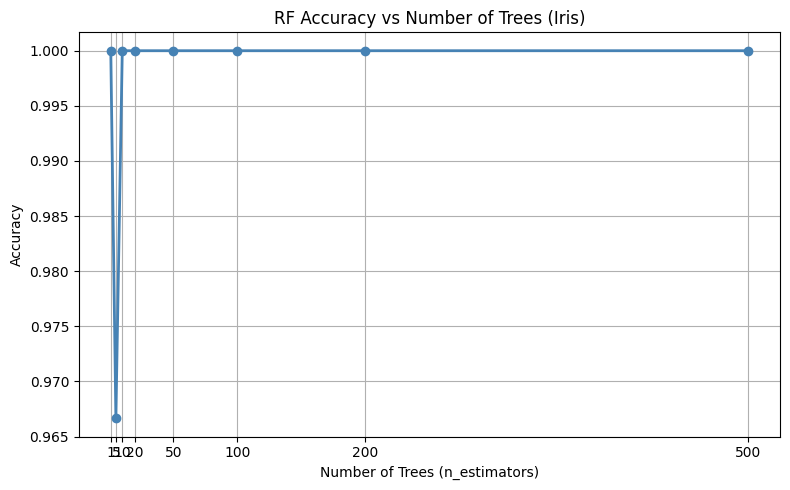


Best Accuracy: 1.0000 with n_estimators=1


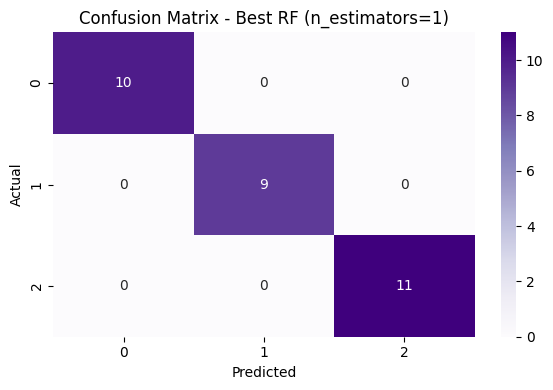

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Reuse same iris X_train, X_test, y_train, y_test from above

# --- Part i: Default n_estimators = 10 ---
rf_default = RandomForestClassifier(n_estimators=10, random_state=42)
rf_default.fit(X_train, y_train)
y_pred_default = rf_default.predict(X_test)
print(f"RF Accuracy (n_estimators=10): {accuracy_score(y_test, y_pred_default):.4f}")

# Confusion Matrix - Default
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_default), annot=True, fmt='d', cmap='Oranges')
plt.title('Confusion Matrix - RF (n_estimators=10)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# --- Part ii: Fine-tuning number of trees ---
tree_counts = [1, 5, 10, 20, 50, 100, 200, 500]
scores = []

for n in tree_counts:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)
    score = accuracy_score(y_test, rf.predict(X_test))
    scores.append(score)
    print(f"n_estimators={n:4d}  ->  Accuracy: {score:.4f}")

# Plot accuracy vs number of trees
plt.figure(figsize=(8, 5))
plt.plot(tree_counts, scores, marker='o', color='steelblue', linewidth=2)
plt.title('RF Accuracy vs Number of Trees (Iris)')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Accuracy')
plt.xticks(tree_counts)
plt.grid(True)
plt.tight_layout()
plt.show()

# Best score
best_idx = scores.index(max(scores))
print(f"\nBest Accuracy: {max(scores):.4f} with n_estimators={tree_counts[best_idx]}")

# Confusion Matrix - Best model
rf_best = RandomForestClassifier(n_estimators=tree_counts[best_idx], random_state=42)
rf_best.fit(X_train, y_train)
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, rf_best.predict(X_test)), annot=True, fmt='d', cmap='Purples')
plt.title(f'Confusion Matrix - Best RF (n_estimators={tree_counts[best_idx]})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()